# Spiral Wave Induction base on Given Phase Map

This tutorial illustraits how induce reentry in specific region if the heart

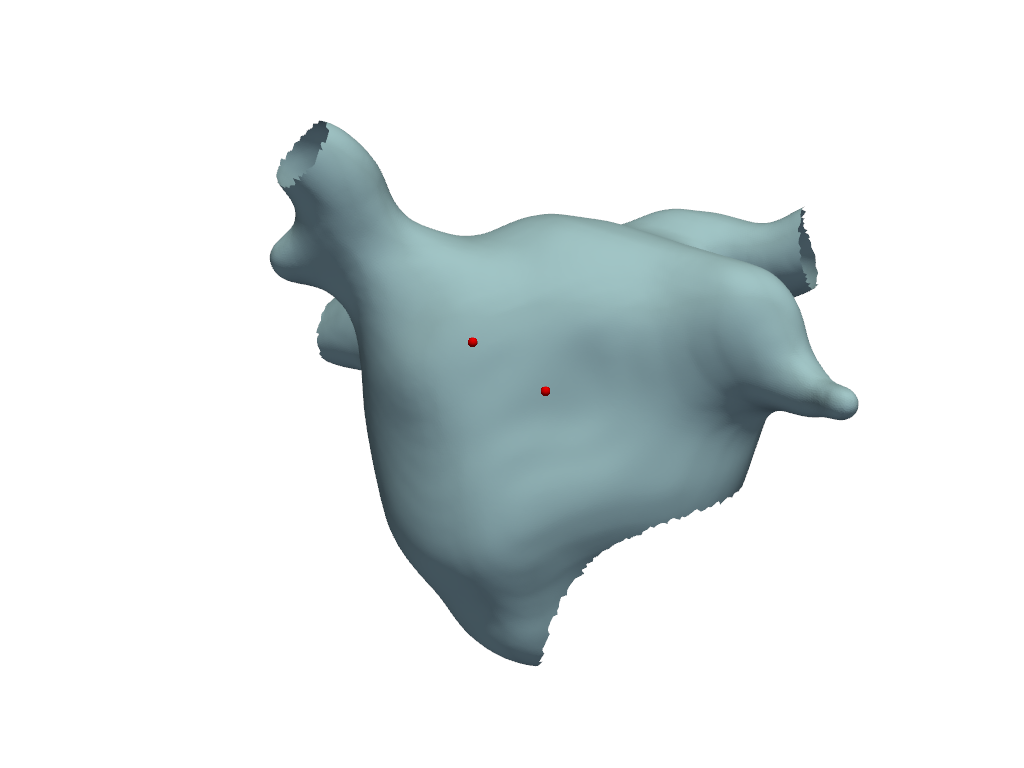

In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv
import numpy as np


path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")
vtk_mesh = pv.read(path / "Mesh_31475951.vtk")

camera_position = [
    (29.5, 169.2, 68.3),
    (-13.3, -26.5, 52.2),
    (0.299, -0.142, 0.943)
]

coords = vtk_mesh.points / 1000
elems = vtk_mesh.faces.reshape(-1, 4)[:, 1:4]
fibers = vtk_mesh.cell_data['fiber_endo']

point_ids = [106429, 57035]

faces = np.hstack([[3, *tri] for tri in elems])
mesh = pv.PolyData(coords, faces)

# set static plot
pv.set_jupyter_backend('static') 

pl = pv.Plotter()
pl.add_mesh(mesh, show_edges=False)
pl.add_points(coords[point_ids], color='red', point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()

## Generate phase map

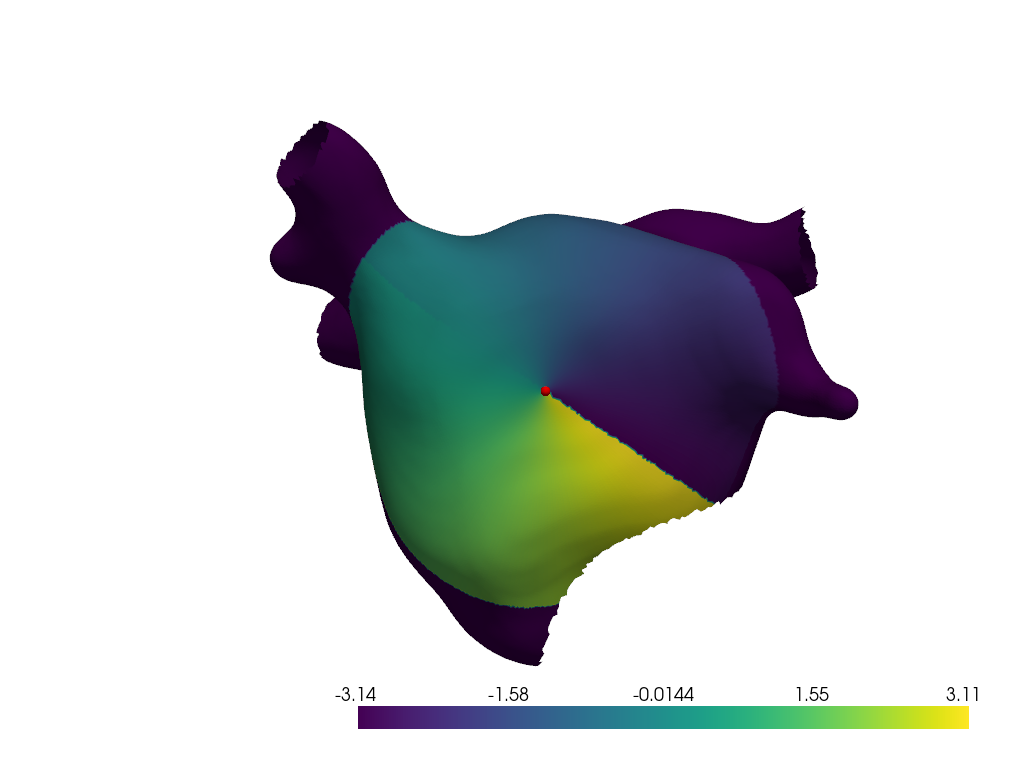

In [2]:
from scipy import spatial


def find_points_within_radius(mesh, point, radius):
    """
    Find indices of points in the mesh that are within a given radius of a specified point.

    Parameters
    ----------
    mesh: pyvista.PolyData
        The input mesh containing the points to search.
    point: array-like of shape (3,)
        The reference point from which to measure distances.
    radius: float
        The radius within which to search for points.

    Returns
    -------  
    indices: list of int
        A list of indices of points in the mesh that are within the specified radius of
        the reference point.
    """
    tree = spatial.cKDTree(mesh.points)
    indices = tree.query_ball_point(point, radius)
    return indices


def project_local_per_vector(x, V, normals, eps=1e-12):
    """
    Project vectors V onto a local coordinate system defined by x and the normals.

    Parameters
    ----------
    x: array-like of shape (3,)
        The reference vector defining the local x-axis.
    V: array-like of shape (N, 3)
        The vectors to be projected.
    normals: array-like of shape (N, 3)
        The normal vectors at each point corresponding to V.
    eps: float, optional
        A small value to handle numerical stability in case of parallel vectors.

    Returns
    -------
    V_out: array of shape (N, 2)
        The projected vectors in the local coordinate system
    """
    x_hat = x / np.linalg.norm(x)
    vx = V @ x_hat
    Y = V - vx[:, None] * x_hat

    vy = np.linalg.norm(Y, axis=1)
    vy[vy < eps] = 0.0
    
    n = np.cross(x_hat, V)
    n_norm = np.linalg.norm(n, axis=1)
    n_norm[n_norm < eps] = 1.0
    n_hat = n / n_norm[:, None]

    sign = np.einsum('ij,ij->i', n_hat, normals)
    vy *= np.sign(sign)

    V_out = np.stack([vx, vy], axis=1)
    return V_out


inds = find_points_within_radius(mesh, coords[point_ids[0]], 30)
mesh = mesh.compute_normals(inplace=True)
normals_0 = mesh.point_normals[inds]

vectors_0 = mesh.points[inds] - coords[point_ids[0]]
x_axis_0 = mesh.points[point_ids[1]] - coords[point_ids[0]]

vectors_0 = project_local_per_vector(x_axis_0, vectors_0, normals_0)

angles_0 = np.arctan2(vectors_0[:, 1], vectors_0[:, 0])

phase_map = np.ones(mesh.n_points) * -np.pi
phase_map[inds] = angles_0

pl = pv.Plotter()
pl.add_mesh(mesh, scalars=phase_map, show_edges=False)
pl.add_points(coords[point_ids[0]], color='red', point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()


## Generate state variables for each phase values

Running Courtemanche on [50, 1] Grid: 100%|██████████| 30000/30000 [00:03<00:00, 9944.68it/s] 


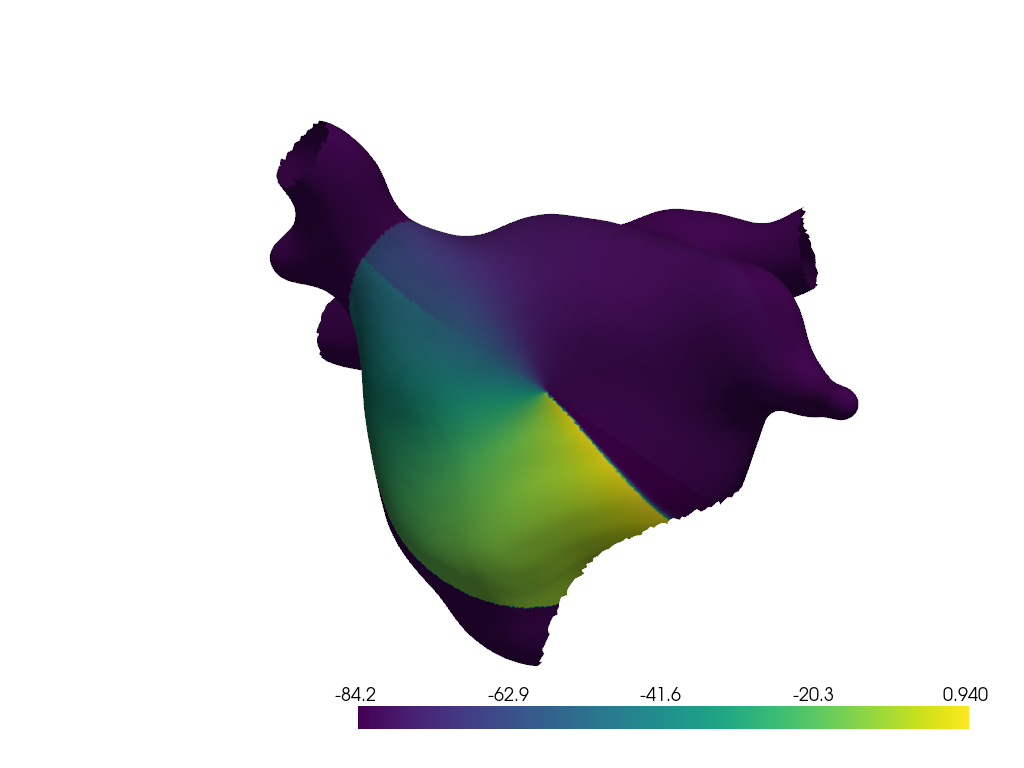

In [ ]:

from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np


stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=30, cycle_length=500, duration=1, curr_value=0.5)

cardiac_model = fw.Courtemanche()
cardiac_model.gk1 *= 2
cardiac_model.gks *= 2
cardiac_model.gkr *= 1.6
cardiac_model.gkur *= 0.5
cardiac_model.gcal *= 0.45
cardiac_model.gto *= 0.35
cardiac_model.ipcamax *= 1.5
cardiac_model.inacamax *= 1.6
cardiac_model.prepacing(stim_prepacing)

# create a tissue of size 50x10 to collect the state variables.
n, m = 50, 1
tissue = fw.CardiacTissueGrid([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="numba")
simulation.dt = 0.01
simulation.t_max = 300

simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
n_levels = len(state_tracker.tracking_times)
state_map = n_levels - np.digitize(phase_map, bins=np.linspace(-np.pi, np.pi, n_levels))
for var_name in cardiac_model.state_vars:
    tracked_values = state_tracker.output[var_name]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array

pl = pv.Plotter()
pl.add_mesh(mesh, scalars=state_vars["u"], show_edges=False)
pl.camera_position = camera_position
pl.show()


## Run simulation

Running Courtemanche on Triangle Elements: 100%|██████████| 30000/30000 [04:19<00:00, 115.55it/s]


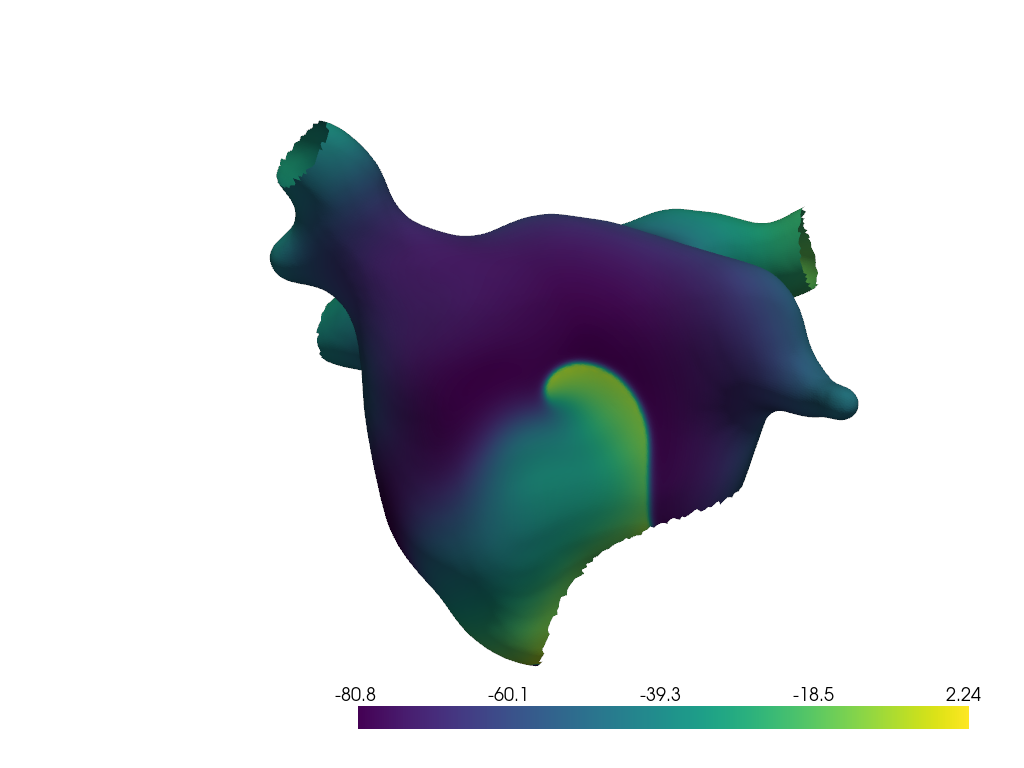

In [ ]:
tissue = fw.CardiacTissueElements(coords, elems, "Triangle")

cardiac_model = fw.Courtemanche()
cardiac_model.gk1 *= 2
cardiac_model.gks *= 2
cardiac_model.gkr *= 1.6
cardiac_model.gkur *= 0.5
cardiac_model.gcal *= 0.45
cardiac_model.gto *= 0.35
cardiac_model.ipcamax *= 1.5
cardiac_model.inacamax *= 1.6

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="mlx")
simulation.dt = 0.01
simulation.t_max = 300
simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.solver = fw.CrankNicolsonSolver()
simulation.solver.atol = 1e-6

simulation.initialize()
simulation.cardiac_model.set_variables(state_vars, update_kernel_args=True)
# run the model:
simulation.run(initialize=False)

# show the potential map at the end of calculations:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars=cardiac_model.u, show_edges=False)
pl.camera_position = camera_position
pl.show()